# =============================
# 1) Setup
# =============================

In [1]:
from google.colab import drive
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

# Install graph package in a fresh Colab runtime
subprocess.run(["pip", "-q", "install", "torch-geometric"], check=True)

from torch_geometric.nn import GATConv
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
drive.mount('/content/drive')


Mounted at /content/drive


In [12]:
# ===== EDIT THESE =====
DATASET_ZIP = "/content/drive/MyDrive/PhD/DataSets/dataset_split.zip"
DATASET_ROOT = "/content/content/dataset_split"
UNSEEN_ZIP = "/content/drive/MyDrive/PhD/DataSets/unseen_images.zip"  # folder with class subfolders
UNSEEN_ROOT = "/content/unseen_images"
MODEL_PATH = "/content/drive/MyDrive/PhD/Models/best_gat_from_efficientnetb0.pth"
TRAIN_ROOT = "/content/content/dataset_split/train"  # class order source
# ======================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [8]:
if not os.path.exists(DATASET_ROOT):
    import subprocess
    subprocess.run(["unzip", "-q", DATASET_ZIP, "-d", "/content/"], check=True)
    print(f"Unzipped dataset into: {DATASET_ROOT}")
else:
    print(f"Dataset already exists at: {DATASET_ROOT}")

for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASET_ROOT, split)
    print(split, "exists:", os.path.isdir(split_path))

Unzipped dataset into: /content/content/dataset_split
train exists: True
val exists: True
test exists: True


In [9]:
if not os.path.exists("/content/content/unseen"):
    import subprocess
    subprocess.run(["unzip", "-q", UNSEEN_ZIP, "-d", "/content/"], check=True)
    print(f"Unzipped dataset into: {"/content/content/unseen"}")
else:
    print(f"Dataset already exists at: {"/content/content/unseen"}")

Unzipped dataset into: /content/content/unseen


# =============================
# 2) Match training GAT architecture
# =============================

In [4]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x


# =============================
# 3) Class mapping (must match training order)
# =============================

In [10]:
def build_class_mapping(train_root: str, unseen_root: str):
    if os.path.isdir(train_root):
        class_names = sorted([
            d for d in os.listdir(train_root)
            if os.path.isdir(os.path.join(train_root, d))
        ])
        print("Using class order from TRAIN_ROOT")
    else:
        class_names = sorted([
            d for d in os.listdir(unseen_root)
            if os.path.isdir(os.path.join(unseen_root, d))
        ])
        print("WARNING: TRAIN_ROOT not found.")
        print("Using class order from UNSEEN_ROOT; ensure it matches training label order.")

    class_to_idx = {cls: i for i, cls in enumerate(class_names)}
    return class_names, class_to_idx


class_names, class_to_idx = build_class_mapping(TRAIN_ROOT, UNSEEN_ROOT)
num_classes = len(class_names)
print("Num classes:", num_classes)



Using class order from TRAIN_ROOT
Num classes: 21


# =============================
# 4) EfficientNet-B0 feature extractor
# =============================

In [13]:
feature_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
feature_model.classifier = nn.Identity()  # 1280-d embedding
feature_model = feature_model.to(DEVICE)
feature_model.eval()

feature_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_unseen_embeddings(unseen_root: str, model, transform, device, class_to_idx):
    embeddings, labels, paths = [], [], []

    for cls_name in sorted(os.listdir(unseen_root)):
        cls_dir = os.path.join(unseen_root, cls_name)
        if not os.path.isdir(cls_dir):
            continue

        if cls_name not in class_to_idx:
            print(f"Skipping class '{cls_name}' (not in training class list)")
            continue

        for fname in tqdm(sorted(os.listdir(cls_dir)), desc=f"Extracting {cls_name}"):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(cls_dir, fname)
            try:
                img = Image.open(img_path).convert("RGB")
                x = transform(img).unsqueeze(0).to(device)
                with torch.no_grad():
                    feat = model(x)
                embeddings.append(feat.squeeze().cpu().numpy())
                labels.append(class_to_idx[cls_name])
                paths.append(img_path)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return (
        np.array(embeddings, dtype=np.float32),
        np.array(labels, dtype=np.int64),
        np.array(paths),
    )


X_unseen, y_unseen, paths_unseen = extract_unseen_embeddings(
    UNSEEN_ROOT, feature_model, feature_transform, DEVICE, class_to_idx
)
print("Unseen embeddings shape:", X_unseen.shape)
print("Unseen labels shape:", y_unseen.shape)

assert len(X_unseen) > 1, "Need at least 2 unseen images to build kNN graph."



Extracting Venkatgiri_Silk: 100%|██████████| 14/14 [00:01<00:00, 12.50it/s]

Unseen embeddings shape: (421, 1280)
Unseen labels shape: (421,)


# =============================
# 5) Build unseen graph with kNN
# =============================

In [14]:
K = min(10, len(X_unseen) - 1)
nbrs = NearestNeighbors(n_neighbors=K + 1, metric="cosine")
nbrs.fit(X_unseen)
_, indices = nbrs.kneighbors(X_unseen)

src, dst = [], []
for i in range(indices.shape[0]):
    for j in indices[i, 1:]:
        src.append(i)
        dst.append(int(j))
        src.append(int(j))
        dst.append(i)

edge_index_np = np.vstack([src, dst])
print("edge_index shape:", edge_index_np.shape)

x_tensor = torch.tensor(X_unseen, dtype=torch.float32)
y_tensor = torch.tensor(y_unseen, dtype=torch.long)
edge_index = torch.tensor(edge_index_np, dtype=torch.long)

data_unseen = Data(x=x_tensor, edge_index=edge_index, y=y_tensor).to(DEVICE)


edge_index shape: (2, 8420)


# =============================
# 6) Load model + evaluate unseen accuracy
# =============================


Unseen Accuracy (GAT on EfficientNet-B0 embeddings): 0.3919

Classification Report (Unseen):
                   precision    recall  f1-score   support

        Baluchari     1.0000    0.5000    0.6667        20
          Banaras     0.0000    0.0000    0.0000        30
    Champa_Tussar     0.1809    1.0000    0.3063        17
   Dhakai_Jamdani     1.0000    0.7000    0.8235        20
           Gadwal     0.0000    0.0000    0.0000        20
            Ilkal     1.0000    0.0556    0.1053        18
        Kalamkari     0.5333    1.0000    0.6957        16
    Kanchi_Cotton     0.5263    1.0000    0.6897        20
       Kanjivaram     0.0408    0.1000    0.0580        20
    Kerala_Kasavu     0.6061    1.0000    0.7547        20
             Kota     0.9091    0.5000    0.6452        20
       Maheshwari     1.0000    0.0500    0.0952        20
       Mangalgiri     0.0000    0.0000    0.0000        20
      Mysore_Silk     0.4444    0.6316    0.5217        19
       Narayanpet   

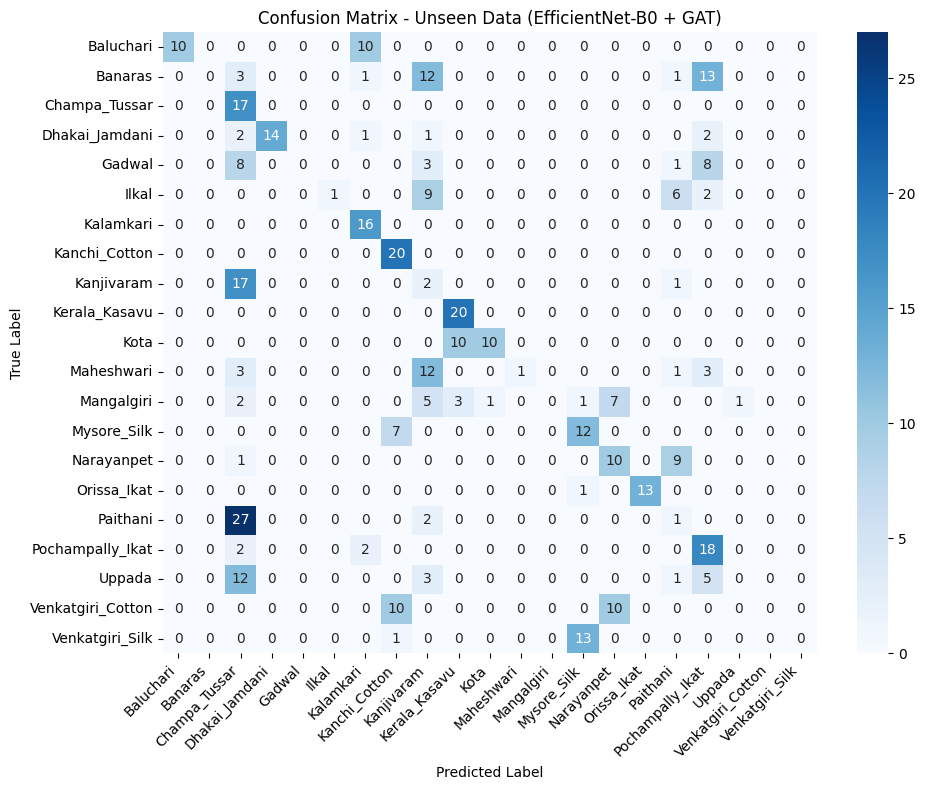


Sample predictions:
000: true=Baluchari, pred=Kalamkari, path=/content/unseen_images/Baluchari/baluchari_1.jpg
001: true=Baluchari, pred=Baluchari, path=/content/unseen_images/Baluchari/baluchari_10.jpg
002: true=Baluchari, pred=Kalamkari, path=/content/unseen_images/Baluchari/baluchari_11.jpg
003: true=Baluchari, pred=Kalamkari, path=/content/unseen_images/Baluchari/baluchari_12.jpg
004: true=Baluchari, pred=Kalamkari, path=/content/unseen_images/Baluchari/baluchari_13.jpg
005: true=Baluchari, pred=Baluchari, path=/content/unseen_images/Baluchari/baluchari_14.jpg
006: true=Baluchari, pred=Kalamkari, path=/content/unseen_images/Baluchari/baluchari_15.jpg
007: true=Baluchari, pred=Baluchari, path=/content/unseen_images/Baluchari/baluchari_16.jpg
008: true=Baluchari, pred=Kalamkari, path=/content/unseen_images/Baluchari/baluchari_17.jpg
009: true=Baluchari, pred=Baluchari, path=/content/unseen_images/Baluchari/baluchari_18.jpg


In [15]:
in_channels = data_unseen.x.shape[1]
gat_model = GAT(
    in_channels=in_channels,
    hidden_channels=128,
    out_channels=num_classes,
    heads=4,
    dropout=0.5,
).to(DEVICE)

state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
gat_model.load_state_dict(state_dict)
gat_model.eval()

with torch.no_grad():
    logits = gat_model(data_unseen.x, data_unseen.edge_index)

pred = logits.argmax(dim=1).cpu().numpy()
true = data_unseen.y.cpu().numpy()

unseen_acc = (pred == true).mean()
print(f"\nUnseen Accuracy (GAT on EfficientNet-B0 embeddings): {unseen_acc:.4f}")

present_labels = sorted(np.unique(true).tolist())
present_names = [class_names[i] for i in present_labels]

print("\nClassification Report (Unseen):")
print(classification_report(
    true,
    pred,
    labels=present_labels,
    target_names=present_names,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(true, pred, labels=present_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=present_names,
    yticklabels=present_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Unseen Data (EfficientNet-B0 + GAT)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nSample predictions:")
for i in range(min(10, len(paths_unseen))):
    print(f"{i:03d}: true={class_names[true[i]]}, pred={class_names[pred[i]]}, path={paths_unseen[i]}")
